## **Numerical Optimization and Large Scale Linear Algebra**

> Lefki Athanasopoulou
	f3352404

### **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist # For Euclidean Distances
import matplotlib.pyplot as plt
from numpy.linalg import lstsq  # For least squares solution
from sklearn.metrics import mean_squared_error
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import cvxpy as cp
from scipy.optimize import differential_evolution


### **GUIDELINES**

### **We have:**
- **$n$ lamps** illuminating an area.
- The area is divided into **$m$ regions (pixels)**.
- **$\mathbf{l}$**: an $m$-vector that gives the illumination levels across all regions  
  - $l_i$: lighting level in region $i$
- **$\mathbf{p}$**: an $n$-vector that gives the set of lamp powers  
  - $p_i$: the power at which lamp $i$ operates
- The illumination vector $\mathbf{l}$ is a linear function of $\mathbf{p}$, so we have  
  $$
  \mathbf{l} = A \mathbf{p}
  $$
  for some matrix $A$.
- **$A$**:
  - An $m \times n$ matrix
  - The $j$-th column gives the illumination pattern for lamp $j$ (i.e., illumination with lamp $j$ at power 1 and others off)
  - Has linearly independent columns (and therefore is "tall")
  - The $i$-th row gives the sensitivity of pixel $i$ to the $n$ lamp powers

### **We seek:**
- Lamp powers that yield a desired illumination pattern $\mathbf{l}_\mathrm{des}$. For instance, $\mathbf{l}_\mathrm{des} = \mathbf{1}$, which is uniform illumination (all ones).
	- We want $\mathbf{p}$ such that $A \mathbf{p} \approx \mathbf{l}_\mathrm{des}$.
- Using least squares, we find $\hat{\mathbf{p}}$ that minimizes:
  $$
  \| A \mathbf{p} - \mathbf{l}_\mathrm{des} \|_2^2.
  $$
- **Example:** $n = 10$ lamps, area is a $25 \times 25$ grid ($m = 625$ pixels, each $1\,\mathrm{m}^2$).  
  The $(x,y)$ positions of lamps and their heights are:  
  $$
  \{(4.1, 20.4, 4), (14.1, 21.3, 3.5), (22.6, 17.1, 6), (5.5, 12.3, 4), (12.2, 9.7, 4)\},
  $$
  $$
  \{(15.3, 13.8, 6), (21.3, 10.5, 5.5), (3.9, 3.3, 5), (13.1, 4.3, 5), (20.3, 4.2, 4.5)\}.
  $$
- Illumination follows an inverse-square law, so $A_{ij}$ is proportional to $d_{ij}^{-2}$, with $d_{ij}$ the 3D distance between pixel $i$ and lamp $j$.
- $A$ is scaled so that if all lamps have power 1, the average illumination level is 1.
- The desired pattern $\mathbf{l}_\mathrm{des} = \mathbf{1}$ corresponds to uniform illumination with value 1.


---


### **Initialize matrix A**

### **Initialization of Parameters and Lamp Positions**
- We define a set of \( n = 10 \) lamps illuminating an area of \( $25 \times 25$ \) meters, discretized into \( m = 625 \) pixels.  
- Each lamp is characterized by its \((x, y)\) position and its height \( z \) above the ground.

The positions and heights of the lamps are given and each tuple \(($x_j, y_j, z_j$)\) represents the location of the \( j \)-th lamp in meters.

In [3]:
n = 10 # number of lamps
m = 625 # number of pixels
lamps = np.array([[4.1, 20.4, 4],[14.1, 21.3, 3.5],[22.6, 17.1, 6],[5.5, 12.3, 4],[12.2, 9.7, 4], [15.3, 13.8, 6],[21.3, 10.5, 5.5],[3.9, 3.3, 5],[13.1, 4.3, 5],[20.3, 4.2, 4.5]])

In [4]:
print(f'The matrix with the (x, y) positions of lamps and their height above floor is:\n {lamps}')

The matrix with the (x, y) positions of lamps and their height above floor is:
 [[ 4.1 20.4  4. ]
 [14.1 21.3  3.5]
 [22.6 17.1  6. ]
 [ 5.5 12.3  4. ]
 [12.2  9.7  4. ]
 [15.3 13.8  6. ]
 [21.3 10.5  5.5]
 [ 3.9  3.3  5. ]
 [13.1  4.3  5. ]
 [20.3  4.2  4.5]]


In [5]:
print(f'The shape of the matrix is: {lamps.shape}')

The shape of the matrix is: (10, 3)


### **Pixel Grid Generation**

- The area to be illuminated is divided into \( $25 \times 25$ \) pixels, resulting in a total of \( m = 625 \) pixels.  
- Each pixel is represented by its \((x, y, z)\) coordinates, where \( z = 0 \) since the pixels are located on the floor.

The pixel grid is generated using `numpy.meshgrid` to create all possible \((x, y)\) coordinate combinations, with \(x\) and \(y\) ranging from 1 to 25:

$$
\{(x_i, y_i, 0) \mid x_i, y_i \in \{1, 2, \dots, 25\}\}
$$


- The final shape of the pixel matrix is \( (625, 3) \), where each row corresponds to a pixel's \((x, y, z)\) position.
- This structured grid will be used to calculate the distance between each pixel and each lamp, which is essential for determining the illumination levels.


In [6]:
# Create the x and y coordinates (from 1 to 25) and use meshgrid to generate all possible (x, y) combinations for the 25x25 grid
x_pixels, y_pixels = np.meshgrid(np.arange(1, 26), np.arange(1, 26), indexing='ij')

# Create the third coordinate (z=0 for all pixels) and stack it with x and y coordinates 
pixels = np.stack([x_pixels.ravel(), y_pixels.ravel(), np.zeros(625)], axis=1)  # shape (625, 3)

In [7]:
print(pixels)

[[ 1.  1.  0.]
 [ 1.  2.  0.]
 [ 1.  3.  0.]
 ...
 [25. 23.  0.]
 [25. 24.  0.]
 [25. 25.  0.]]


### **Computation of Squared Euclidean Distances**

- To determine the illumination at each pixel, we need the distance between each pixel and each lamp.  
- The illumination follows an **inverse-square law**, meaning that the contribution of a lamp to a pixel's illumination is inversely proportional to the square of the distance between them.

The **squared Euclidean distance** between the \( i \)-th pixel \($(x_i, y_i, z_i)$\) and the \( j \)-th lamp \($(x_j, y_j, z_j)$\) is given by:

$$
d_{ij}^2 = (x_i - x_j)^2 + (y_i - y_j)^2 + (z_i - z_j)^2
$$

- Since all pixels lie on the floor, \( $z_i$ = 0 \), simplifying the equation to:
  
$$
d_{ij}^2 = (x_i - x_j)^2 + (y_i - y_j)^2 + z_j^2
$$

- The distances are computed using `scipy.spatial.distance.cdist` with the `'sqeuclidean'` metric, which efficiently calculates all pairwise squared distances between pixels and lamps.




In [8]:
# Compute distances (Euclidean squared)
distances = cdist(pixels, lamps, 'sqeuclidean')
print(distances[0]) 

[401.97 595.95 761.77 163.94 217.13 404.33 532.59  38.7  182.3  402.98]


### **Construction of the Illumination Matrix \( A \)**


Mathematically, the illumination matrix \( A \) is defined as:

$$
A_{ij} = \frac{1}{d_{ij}^2}
$$

where:
- \( $A_{ij}$ \) represents the **illumination contribution** of the \( j \)-th lamp to the \( i \)-th pixel.
- \( $d_{ij}^2$ \) is the **squared Euclidean distance** between pixel \( i \) and lamp \( j \).



### **Matrix Dimensions and Structure**:
- The resulting matrix \( A \) has dimensions \( $625 \times 10$ \), where:
  - Each **row** corresponds to a **pixel**.
  - Each **column** corresponds to a **lamp**.



In [9]:
A = 1/distances
print(A)

[[0.00248775 0.00167799 0.00131273 ... 0.02583979 0.00548546 0.00248151]
 [0.00274597 0.00179743 0.00136879 ... 0.02849003 0.00565931 0.00251522]
 [0.00304535 0.00192771 0.00142578 ... 0.02985075 0.00577701 0.00253691]
 ...
 [0.00217595 0.00746547 0.01305995 ... 0.00116509 0.00193686 0.00252666]
 [0.00214698 0.00722804 0.01118944 ... 0.00111272 0.00180278 0.00230213]
 [0.00210984 0.00690846 0.00959969 ... 0.00106259 0.00168039 0.00210535]]


In [10]:
A.shape

(625, 10)

### **Illumination for Each Pixel**

For each pixel \( i \), the illumination is given by:

$$
l_i = \sum_{j=1}^{n} A_{ij}
$$



### **Average Illumination**

The average illumination is the sum of the illumination of all pixels divided by the number of pixels \( m \):

$$
\text{Average Illumination} = \frac{1}{m} \sum_{i=1}^{m} l_i = \frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{n} A_{ij}
$$


In other words, we sum all the elements of \( A \) (i.e., the sum of all $( A_{ij})$ ) and divide by the number of pixels \( m \).



### **Scaling of \( A \)**

To scale the matrix \( A \) so that when all lamps have power 1 the average illumination is 1, divide every element of \( A \) by the average illumination:

$$
A_{\text{scaled}} = \frac{A}{\text{Average Illumination}}
$$


In [11]:
scale = np.sum(A) / m  # Total sum divided by total number of pixels
A_scaled = A / scale     # Scaled matrix

print(f'The scaled matrix is: \n {A_scaled}')

The scaled matrix is: 
 [[0.0259771  0.01752163 0.01370757 ... 0.2698195  0.05727929 0.02591199]
 [0.02867346 0.01876879 0.01429297 ... 0.2974933  0.05909459 0.02626393]
 [0.03179954 0.02012918 0.01488803 ... 0.31170193 0.0603236  0.02649047]
 ...
 [0.02272127 0.07795457 0.13637214 ... 0.01216593 0.0202247  0.02638338]
 [0.02241882 0.07547535 0.11684027 ... 0.01161902 0.01882462 0.02403889]
 [0.02203096 0.07213827 0.10024013 ... 0.01109554 0.01754666 0.02198411]]


---

### **Question 1**

#### Using colormap, create two graphs to show the illumination of the two patterns: 
 - All lamps set to 1 
 - Minimize the sum square deviation with a desired uniform illumination

#### Which are the Root Mean Squared (RMS) errors in both cases?

---

#### **Illumination Pattern with All Lamps Set to 1**

In this scenario, we evaluate the illumination pattern when **all lamps are operating at power = 1**. 

#### **Steps:**

1. **Desired Illumination Pattern**  
   - The target illumination pattern \( $\mathbf{l}_{\text{des}}$ \) is defined as:
   $$
   \mathbf{l}_{\text{des}} = \mathbf{1}
   $$

2. **Predicted Illumination with All Powers Set to 1**  
   - The predicted illumination \( $\mathbf{l}_{\text{pred}}$ \) when all lamps have power equal to 1 is computed as:
   $$
   \mathbf{l}_{\text{pred}} = A_{\text{scaled}} \cdot \mathbf{1}
   $$
   where:
   - \( $A_{\text{scaled}}$ \) is the scaled illumination matrix ensuring that the **average illumination is 1** when all lamp powers are equal to 1.
   - \( $\mathbf{1}$ \) is a vector of ones, indicating full power for all lamps.

3. **Mean Illumination**  
   - The mean illumination across all pixels is given by:
   $$
   \text{Mean Illumination} = \frac{1}{m} \sum_{i=1}^{m} l_{\text{pred}, i}
   $$
   where \( m = 625 \) (total pixels).

4. **Root Mean Squared Error (RMS Error)**  
   - To measure how closely the actual illumination matches the desired uniform illumination, we calculate the **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)**:
   $$
   \text{MSE} = \frac{1}{m} \sum_{i=1}^{m} \left(l_{\text{pred}, i} - l_{\text{des}, i}\right)^2
   $$
   $$
   \text{RMSE} = \sqrt{\text{MSE}}
   $$


- **Mean Illumination:**  
  Shows the **average illumination** across all pixels when all lamps are set to power 1.

- **RMS Error:**  
  The **RMS error** provides a measure of how **uniform** the illumination is compared to the desired uniform pattern.  
  - A **lower RMS error** indicates a **more uniform** illumination.  



In [12]:
l_des = np.ones(m) # The desired l set to 1

illumination_ones = np.ones(n)
l_pred_ones = A_scaled @ illumination_ones

print(f"The mean illumination when lamps set to 1 is: {np.mean(l_pred_ones)}")

The mean illumination when lamps set to 1 is: 1.0


In [13]:
mse_ones = mean_squared_error(l_des, l_pred_ones)

rmse_ones = (mse_ones)**(1/2)
print(f"RMS error (all lamps at power 1): {rmse_ones:.4f}")

RMS error (all lamps at power 1): 0.2459


#### **Colormap Visualization: Illumination with All Lamps Set to 1**

In this section, we visualize the **illumination pattern** when **all lamps are set to power 1**.



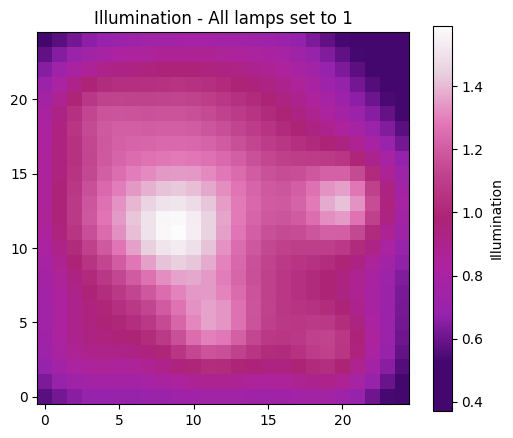

In [14]:
# Colormap for lamps set to 1
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#43076e', '#43076e', '#9623ad', '#ad23a0', '#ad2376','#c24690', '#e378b8','#e8cfde', '#fcfcfc'])
l_pred_ones_grid = l_pred_ones.reshape(25, 25)
plt.figure(figsize=(6, 5))
plt.title("Illumination - All lamps set to 1")
plt.imshow(l_pred_ones_grid, cmap=custom_cmap, origin='lower')
plt.colorbar(label='Illumination')
plt.show()

#### **Least Squares Optimization for Lamp Powers**

In this section, we use the **least squares method** to find the **optimal lamp power distribution** that **minimizes the deviation** from the **desired uniform illumination** pattern.



#### **Objective:**
- The goal is to find the vector of lamp powers \( $\mathbf{p}$ \) that minimizes the following expression:

$$
\hat{\mathbf{p}} = \arg\min_{\mathbf{p}} \| A_{\text{scaled}} \mathbf{p} - \mathbf{l}_{\text{des}} \|_2^2
$$

where:  
- \( $A_{\text{scaled}}$ \) is the **scaled illumination matrix**, ensuring an average illumination of 1 when all lamp powers are 1.  
- \( $\mathbf{l}_{\text{des}}$ \) is the **desired illumination vector** (uniform illumination, all ones).  
- \( $\mathbf{p}$ \) is the vector of **lamp powers** we aim to optimize.



#### **Steps:**

1. **Least Squares Solution**  
   - The **least squares problem** is solved using `numpy.linalg.lstsq`, which computes:
 	$$
    \hat{\mathbf{p}}, \text{residuals}, \text{rank}, \mathbf{s} = \text{lstsq}(A_{\text{scaled}}, \mathbf{l}_{\text{des}})
	$$
   - **Outputs:**
     - \( $\hat{\mathbf{p}} $\): Optimal lamp power distribution.
     - **residuals**: Sum of squared residuals.
     - **rank**: Rank of \( $A_{\text{scaled}}$ \).
     - \( $\mathbf{s} $\): Singular values of \($ A_{\text{scaled}}$ \).



2. **Predicted Illumination**  
   - The predicted illumination pattern based on the optimal lamp powers is computed as:
$$
	\mathbf{l}_{\text{pred}} = A_{\text{scaled}} \hat{\mathbf{p}}
$$


3. **Mean Illumination**  
   - The mean illumination across all pixels is:
    $$
     \text{Mean Illumination} = \frac{1}{m} \sum_{i=1}^{m} l_{\text{pred}, i}
    $$

4. **Root Mean Squared Error (RMS Error)**  
   - To assess the error of the solution, we calculate:
    $$
     \text{MSE} = \frac{1}{m} \sum_{i=1}^{m} \left( l_{\text{pred}, i} - l_{\text{des}, i} \right)^2
    $$
    $$
     \text{RMSE} = \sqrt{\text{MSE}}
    $$




In [15]:
p_ls, residuals, rank, s = np.linalg.lstsq(A_scaled, l_des, rcond=None)

l_pred_ls = A_scaled @ p_ls
print(f"The mean illumination is: {np.mean(l_pred_ls): .4f}")

The mean illumination is:  0.9787


In [16]:
mse_ls = mean_squared_error(l_des, l_pred_ls)

rmse_ls = (mse_ls)**(1/2)
print(f"RMS error (least squares error): {rmse_ls:.4f}")

RMS error (least squares error): 0.1458


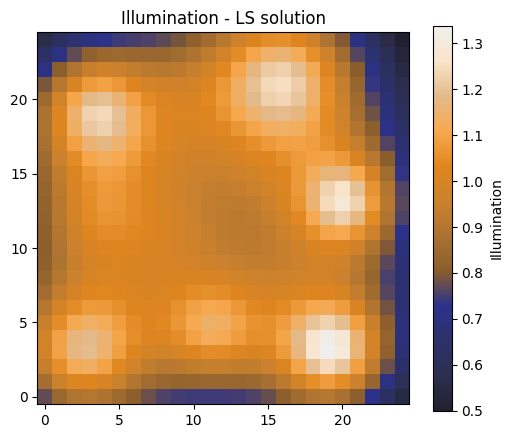

In [17]:
# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#202130', '#2c2f4f', '#2d3169', '#2c328a', '#8a5e2c','#ab7232', '#cc822d','#e0861f', '#f7a94f','#e3ba8a', '#fae4ca', '#f0efed'])

# Colormap for least squares solution
l_pred_ls_grid = l_pred_ls.reshape(25, 25)
plt.figure(figsize=(6, 5))
plt.title("Illumination - LS solution")
plt.imshow(l_pred_ls_grid,  cmap=custom_cmap, origin='lower')
plt.colorbar(label='Illumination')
plt.show()


#### **Colormap Interpretation with RMS Errors**

#### **1. Illumination - All Lamps Set to 1**  
- **Observation:** The illumination is highest near the center, with darker areas (lower illumination) toward the edges.  
- **Uniformity:** The pattern shows uneven lighting.  
- **RMS Error:** 0.2459 — Indicates deviation from the desired uniform illumination.



#### **2. Illumination - LS Solution**  
- **Observation:** The illumination is more evenly distributed across the area, with fewer extreme bright or dark regions.  
- **Uniformity:** A more balanced pattern.  
- **RMS Error:** 0.1458 — A lower RMS error shows improved uniformity.



#### Conclusion 
The LS solution provides a notably more uniform illumination pattern, as reflected in the lower RMS error (0.1458 vs. 0.2459). By optimizing lamp powers, it reduces over-illumination near lamp intersections and improves lighting in previously dim areas.

---

### **Question 2**
Create the histogram of patch illumination values for all lamp powers one, and for lamp powers found by LS.


---

#### 1. **Histogram of Illumination when lamps are set to 1**

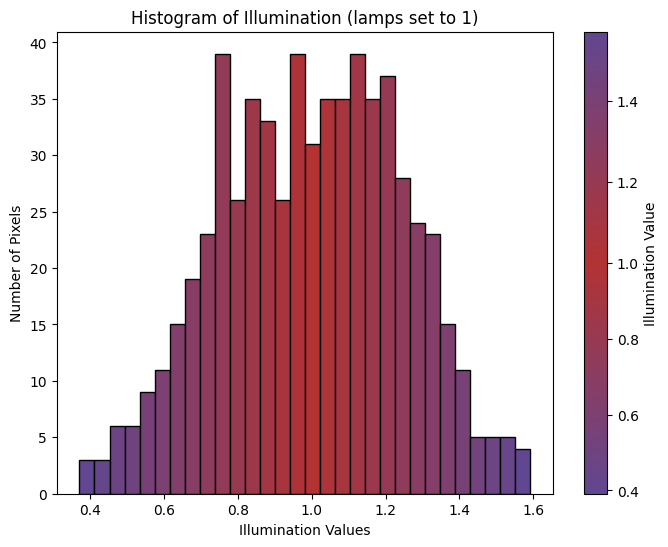

In [18]:
# create hist and patches
fig, ax = plt.subplots(figsize=(8, 6))
counts, bins, patches = ax.hist(l_pred_ones, bins=30, edgecolor='black')

# Compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#614791', '#b33232', '#614791'])

# Initialize the norm with bin center == 1
norm = TwoSlopeNorm(vmin=bin_centers.min(), vcenter=1, vmax=bin_centers.max())

# Map colors to each bar based on the center of the bin
for center, patch in zip(bin_centers, patches):
    color = custom_cmap(norm(center))
    patch.set_facecolor(color)

ax.set_title('Histogram of Illumination (lamps set to 1)')
ax.set_xlabel('Illumination Values')
ax.set_ylabel('Number of Pixels')

# Create colorbar and initialize ax 
sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Illumination Value')

plt.show()


#### 2. **Histogram of Illumination with least squares solution**

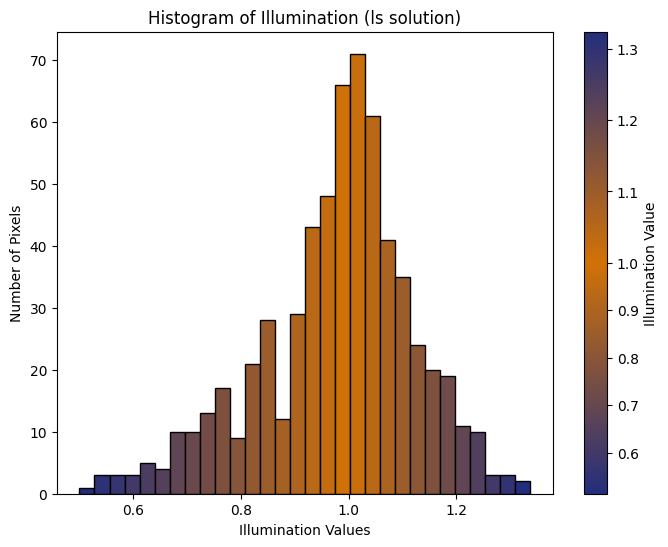

In [2]:
# create hist and patches
fig, ax = plt.subplots(figsize=(8, 6))
counts, bins, patches = ax.hist(l_pred_ls, bins=30, edgecolor='black')

# Compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#242d7d', '#d17206', '#242d7d'])

# Initialize the norm with bin center == 1
norm = TwoSlopeNorm(vmin=bin_centers.min(), vcenter=1, vmax=bin_centers.max())

# Map colors to each bar based on the center of the bin
for center, patch in zip(bin_centers, patches):
    color = custom_cmap(norm(center))
    patch.set_facecolor(color)

ax.set_title('Histogram of Illumination (ls solution)')
ax.set_xlabel('Illumination Values')
ax.set_ylabel('Number of Pixels')

# Create colorbar and initialize ax 
sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])  
fig.colorbar(sm, ax=ax, label='Illumination Value')

plt.show()


### **Histogram Interpretation**

#### **1. All Lamps Set to 1**  
- The illumination values are centered around 1 but range from ~0.8 to ~1.2, indicating non-uniform lighting.  
- The wide spread shows that equal lamp powers do not achieve uniform illumination due to varying pixel distances from the lamps.


#### **2. Least Squares (LS) Solution**  
- The distribution is more concentrated around 1, with a sharper peak, showing improved uniformity.  
- Although the range is broader (~0.6 to ~1.3), more pixels have illumination closer to 1, indicating that LS optimization effectively minimizes overall deviation for a more uniform lighting pattern.

---

### **Question 3**

- The total energy consumption of the lamps will be equal 10 and non of them could be negative. 
- Find the new power distribution of the lamps in order to ensure the least square (under constraints) optimality.

---

#### **Constrained Least Squares Optimization**

In this section, we solve the **least squares optimization problem** under the following **constraints**:
- **Non-negative lamp powers** (\( $p_i \geq 0 $\) for all \( i \)).
- **Total lamp power** equals **10** (\( $\sum_{i=1}^{n}$ $p_i = 10$ \)).



####  **Optimization:**

We aim to minimize the **squared error** between the predicted illumination \( $\mathbf{l}_{\text{pred}}$ \) and the desired uniform illumination \( $\mathbf{l}_{\text{des}}$ \):

$$
\min_{\mathbf{p}} \| A_{\text{scaled}} \mathbf{p} - \mathbf{l}_{\text{des}} \|_2^2
$$

**Subject to:**
$$
p_i \geq 0 \quad \forall i
$$
$$
\sum_{i=1}^{n} p_i = 10
$$

where:
- \( $A_{\text{scaled}}$ \) is the **scaled illumination matrix**.  
- \( $\mathbf{p}$ \) is the vector of **lamp powers**.  
- \( $\mathbf{l}_{\text{des}} = \mathbf{1}$ \) represents **uniform illumination** (all pixels at intensity 1).


#### **Steps in Code:**

1. **Define the Optimization Variable:**  
   - **`p = cp.Variable(n, nonneg=True)`**  
     Ensures all lamp powers \( $p_i$ \) are **non-negative**.

2. **Objective Function:**  
   - **`cp.Minimize(cp.sum_squares` ( \( $A_{\text{scaled}}$ @ \( p - $l_{des}$\)))`)`**  
     Minimizes the **squared deviation** between the predicted and desired illumination.

3. **Constraint:**  
   - **`cp.sum(p) == 10`**  
     Enforces that the **total power** allocated to all lamps is **10**.


#### **Evaluation of the Solution:**

- **Predicted Illumination**


- **RMS Error (Constrained Case)**




In [20]:
# Define the variable for lamp powers (non-negative)
p = cp.Variable(n, nonneg=True)

# Define the objective: minimize the squared error
objective = cp.Minimize(cp.sum_squares(A_scaled @ p - l_des))

# Define the constraint: sum of powers equals 10
constraints = [cp.sum(p) == 10]

# Formulate the problem
problem = cp.Problem(objective, constraints)

# Solve the problem
result = problem.solve()

# The optimized lamp powers
print("Optimal lamp powers:", p.value)


Optimal lamp powers: [1.33396005 0.90625658 2.50937552 0.76930871 0.33730047 0.
 0.3876114  1.66064932 0.72366101 1.37187694]


In [29]:
l_constrained = A_scaled @ p.value
mse_constrained = mean_squared_error(l_des, l_constrained)

rmse_constrained = (mse_constrained)**(1/2)
print(f"RMS error (least squares error constrained): {rmse_constrained:.4f}")

RMS error (least squares error constrained): 0.1598


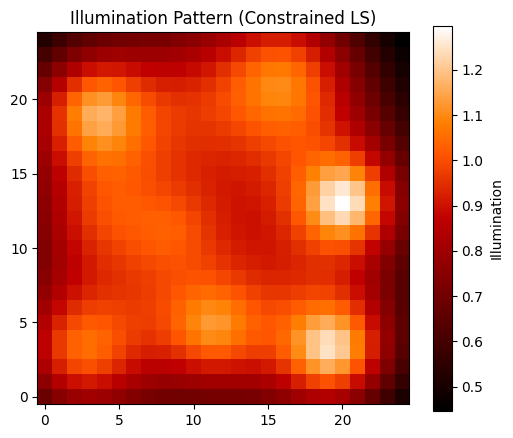

In [30]:
l_constrained_grid = l_constrained.reshape(25, 25)
plt.figure(figsize=(6, 5))
plt.title("Illumination Pattern (Constrained LS)")
plt.imshow(l_constrained_grid,  cmap='gist_heat', origin='lower')
plt.colorbar(label='Illumination')
plt.show()


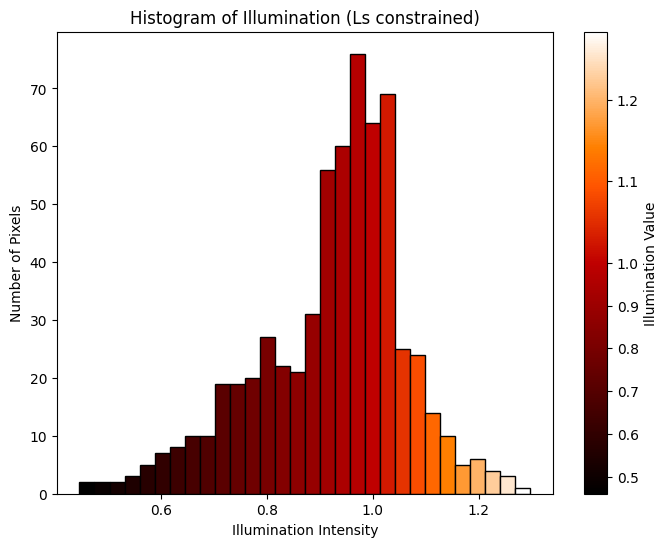

In [34]:
# create hist and patches
fig, ax = plt.subplots(figsize=(8, 6))
counts, bins, patches = ax.hist(l_constrained, bins=30, edgecolor='black')

# Compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Initialize the norm with bin center == 1
norm = TwoSlopeNorm(vmin=bin_centers.min(), vcenter=1, vmax=bin_centers.max())

# Map colors to each bar based on the center of the bin
for center, patch in zip(bin_centers, patches):
    color =  plt.cm.gist_heat(norm(center))
    patch.set_facecolor(color)

ax.set_title('Histogram of Illumination (Ls constrained)')
ax.set_xlabel('Illumination Intensity')
ax.set_ylabel('Number of Pixels')

# Create colorbar and initialize ax 
sm = plt.cm.ScalarMappable(norm=norm, cmap='gist_heat')
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Illumination Value')


plt.show()


#### **Insights on the Illumination Distribution**  
- The histogram shows that **most pixels** have illumination **centered around 1.0**, meaning the constrained least squares optimization **successfully minimized deviations** from the desired uniform illumination.  
- The **distribution is slightly skewed**, with some pixels receiving **lower illumination (<0.7)** and a few **higher (>1.2)**, indicating **non-perfect uniformity** but overall balanced lighting.  
- There are **some darker areas** (low illumination) and **hotspots** (higher illumination), likely due to **lamp positioning and power constraints**.  


---

### **Question 4**

**Find, new points for the lamps to beat the RMS error of the first question.** 
- The lamps can be in any height between 4 and 6 (inside the area)
- The total energy of the lamps should be 10 and non of them should be negative.
Run different -random-choices of positions until you find a better solution. For this choice of points, create present the colormap picture of the illumination as well as the histogram of the intensities of the pixels of the area.


---

### **4.1 First Approach**

#### **Random Search for Optimal Lamp Positions**

In this section, we conduct a **random search** to explore different **lamp configurations** and identify a placement that **minimizes the RMS error**. This approach ensures that **random choices of lamp positions** are tested until a **better solution** than the least squares baseline is found.



#### **Implementation Details:**
####  **Computing the RMS Error for a Given Lamp Configuration**
- The function **`compute_rms_error_and_illumination(lamp_positions)`**:
  - Computes **squared Euclidean distances** from **each pixel** to **each lamp**.
  - Constructs the **illumination matrix** \( A \) using the **inverse-square law**.
  - Scales \( A \) to ensure an **average illumination of 1**.
  - Solves a **constrained least squares problem** to find the **lamp power distribution** (\( $p_i \geq 0$ \), \( $\sum p_i = 10$ \)).
  - Computes the **RMS error** for the given **random lamp positions**.




In [ ]:
max_trials = 1000  # Maximum number of random trials

# Function to compute RMS error for given lamp positions
def compute_rms_error_and_illumination(lamp_positions):
    # Distances from each pixel to each lamp
    distances = cdist(pixels, lamp_positions, 'sqeuclidean')
    A = 1 / distances
    scale = np.sum(A) / m
    A_scaled = A / scale

    # Constrained least squares optimization for lamp powers
    p = cp.Variable(n, nonneg=True)
    objective = cp.Minimize(cp.sum_squares(A_scaled @ p - l_des))
    constraints = [cp.sum(p) == 10]
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Compute illumination and RMS error
    l_final = A_scaled @ p.value
    rms_error = np.sqrt(np.mean((l_final - l_des) ** 2))
    return rms_error, l_final, lamp_positions, p.value


#### **Running a Random Search**
- We **randomly generate lamp positions** and compute the **RMS error** for each configuration.
- The algorithm **stops as soon as a better RMS error** is found.
- **Bounds for random positions**:
  - **\( x, y \) positions**: Between \([1, 25]\) meters.
  - **\( z \) height**: Between \([4, 6]\) meters.


In [ ]:
# Random search until better RMS error is found
best_rms_error = np.inf
best_illumination = None
best_positions = None
best_powers = None

np.random.seed(42)  # Set the random seed for reproducibility


for trial in range(1, max_trials + 1):
    # Random lamp positions: x, y ∈ [1, 25], z ∈ [4, 6]
    random_positions = np.column_stack((
        np.random.uniform(1, 25, n),
        np.random.uniform(1, 25, n),
        np.random.uniform(4, 6, n)
    ))

    # Compute RMS error for the random set
    rms_error, illumination, lamp_positions, lamp_powers = compute_rms_error_and_illumination(random_positions)

    # Check if better solution found
    if rms_error < rmse_ls:
        best_rms_error, best_illumination, best_positions, best_powers = rms_error, illumination, lamp_positions, lamp_powers
        print(f"Better solution found at trial {trial}: RMS Error = {rms_error:.4f}")
        break
    else:
        print(f"Trial {trial}: RMS Error = {rms_error:.4f} (no improvement)")


Trial 1: RMS Error = 0.3467 (no improvement)
Trial 2: RMS Error = 0.3000 (no improvement)
Trial 3: RMS Error = 0.2097 (no improvement)
Trial 4: RMS Error = 0.1832 (no improvement)
Trial 5: RMS Error = 0.2550 (no improvement)
Trial 6: RMS Error = 0.3458 (no improvement)
Trial 7: RMS Error = 0.2278 (no improvement)
Better solution found at trial 8: RMS Error = 0.1389


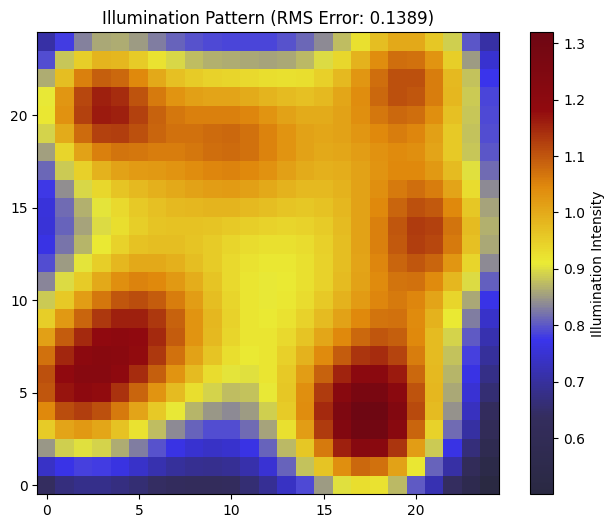

In [111]:
# Reshape illumination for plotting
illumination_grid = best_illumination.reshape(25, 25)

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#2a2942', '#342d5e', '#3a34eb','#ebeb34', '#e0890d', '#910a0f', '#6e0713'])

# Colormap of illumination
plt.figure(figsize=(8, 6))
plt.title(f"Illumination Pattern (RMS Error: {best_rms_error:.4f})")
plt.imshow(illumination_grid, cmap=custom_cmap, origin='lower')
plt.colorbar(label='Illumination Intensity')

plt.show()


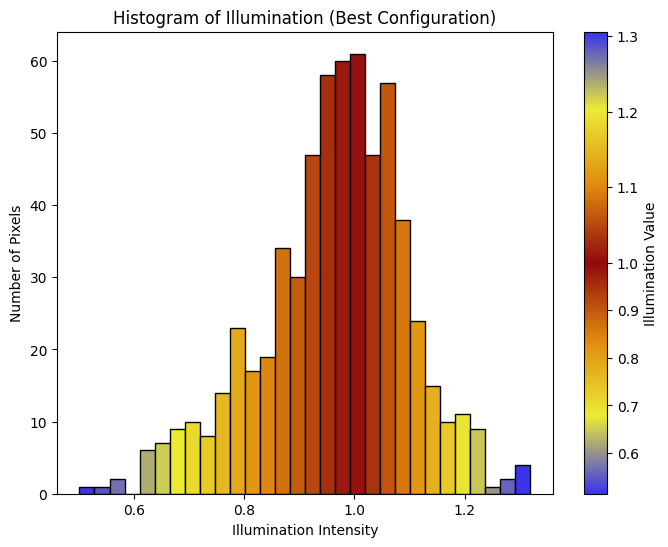

Final RMS Error: 0.1389
Best lamp positions (x, y, height):
 [[23.58678097 20.99586987  5.42601459]
 [20.58445965  5.93904825  5.53971931]
 [ 4.15347053 18.53632481  4.66149405]
 [ 9.31912036 20.28193994  4.4572205 ]
 [ 6.00405987  2.03509687  5.25268792]
 [21.81715689  3.5724977   4.8289585 ]
 [20.01592526 11.4420076   5.87356214]
 [ 9.37603938  6.30114932  5.28490484]
 [14.65937277 22.13492959  4.77380069]
 [20.32315697 18.27250091  5.71023932]]
Corresponding lamp powers:
 [1.69555259e+00 5.80244514e-22 1.66158091e+00 2.74410456e-01
 1.64946875e+00 1.41604239e+00 1.27926900e+00 1.02716739e+00
 9.96508501e-01 1.87571747e-21]


In [90]:
# create hist and patches
fig, ax = plt.subplots(figsize=(8, 6))
counts, bins, patches = ax.hist(best_illumination, bins=30, edgecolor='black')

# Compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#3a34eb','#ebeb34', '#e0890d', '#910a0f','#e0890d',  '#ebeb34', '#3a34eb'])

# Initialize the norm with bin center == 1
norm = TwoSlopeNorm(vmin=bin_centers.min(), vcenter=1, vmax=bin_centers.max())

# Map colors to each bar based on the center of the bin
for center, patch in zip(bin_centers, patches):
    color = custom_cmap(norm(center))
    patch.set_facecolor(color)

ax.set_title('Histogram of Illumination (Best Configuration)')
ax.set_xlabel('Illumination Intensity')
ax.set_ylabel('Number of Pixels')

# Create colorbar and initialize ax 
sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Illumination Value')


plt.show()


# Final results
print(f"Final RMS Error: {best_rms_error:.4f}")
print("Best lamp positions (x, y, height):\n", best_positions)
print("Corresponding lamp powers:\n", best_powers)



### **4.2 Alternative Optimized solution**

#### **Lamp Positions Using Differential Evolution**

In this section, we optimize the **lamp positions** to minimize the **Root Mean Squared (RMS) error** of the illumination pattern. We employ **Differential Evolution (DE)**, an optimization algorithm, to explore different configurations of lamp placements.


#### **Objective:**
- The goal is to find the optimal set of lamp positions \( (x, y, z) \) that minimizes the RMS error
  where:
  - \( $A_{\text{scaled}}$ \) is the **scaled illumination matrix**.
  - \( $\mathbf{p}$ \) is the **optimized power distribution** for a given set of lamp positions.
  - \( $\mathbf{l}_{\text{des}} = \mathbf{1}$ \) represents the **desired uniform illumination**.
  - \( m \) is the total number of pixels.



#### **Computing the RMS Error for a Given Lamp Configuration**
- The function **`compute_rms_error(lamps)`**:
  - Ensures that the lamp positions are in the correct **(n, 3)** shape.
  - Computes the **squared Euclidean distances** between each pixel and each lamp.
  - Constructs the illumination matrix \( A \) using the **inverse-square law**
  - Scales \( A \) so that the **average illumination is 1** if all lamps have power 1.
  - Solves the **constrained least squares problem** using **CVXPY** to optimize lamp powers (\( $p_i \geq 0$ \), \( $\sum p_i = 10$ \)).
  - Computes the **RMS error** for this configuration.



In [ ]:
def compute_rms_error(lamps):
    # Ensure lamps is a 2D array of shape (n, 3)
    lamps = np.array(lamps).reshape((n, 3))
    
    # Compute distances (squared Euclidean)
    distances = cdist(pixels, lamps, 'sqeuclidean')
    
    # Compute matrix A 
    A = 1 / distances
    
    # Scale A so that the average illumination is 1.
    scale = np.sum(A) / m
    A_scaled = A / scale
    
    # Solve the constrained least squares problem using CVXPY
    p = cp.Variable(n, nonneg=True)
    objective = cp.Minimize(cp.sum_squares(A_scaled @ p - l_des))
    constraints = [cp.sum(p) == 10]
    problem = cp.Problem(objective, constraints)
    
    problem.solve()
    
    l_constrained = A_scaled @ p.value
    rms_error = np.sqrt(np.mean((l_constrained - l_des) ** 2))
    return rms_error



#### **Early Stopping with a Callback Function**
- **`simple_callback(x, convergence)`** monitors the optimization process:
  - Tracks the **best RMS error** found so far.
  - Implements a **patience mechanism**:  
    - If no improvement is observed for **20 iterations**, the optimization is **terminated early** to save computational resources.


In [38]:
# Define global variables for early stopping
best_val_loss = float('inf')
no_improve = 0
patience = 20  # number of iterations to wait

def simple_callback(x, convergence):
    global best_val_loss, no_improve
    current_loss = compute_rms_error(x)
    
    if current_loss < best_val_loss:
        best_val_loss = current_loss
        no_improve = 0
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} iterations.")
    
    if no_improve >= patience:
        print("Early stopping triggered.")
        return True  # Stop the optimization
    return False


#### **Setting the Bounds for Lamp Positions**
- Each lamp is constrained within:
  - **\( x, y \) positions:** \([1, 25]\) meters (within the illuminated area).
  - **\( z \) height:** \([4, 6]\) meters.



#### **Using Differential Evolution for Optimization**
- **Differential Evolution (DE)** is used to explore **random lamp positions** while systematically improving towards a **better solution**.

- Key parameters:
  - **`strategy='randtobest1bin'`** → Directs the search towards the **best solution found so far** while maintaining **random exploration**.
  - **`maxiter=100`** → Allows a **maximum of 100 generations**.
  - **`popsize=15`** → Determines **population size** (higher values increase diversity but slow down convergence).
  - **`tol=0.01`** → Stops when **the best and worst solutions differ by less than 1%**.
  - **`seed=42`** → Ensures **reproducibility**.
  - **`disp=True`** → Displays **optimization progress**.
  - **`vectorized=False`** → Evaluates **one candidate solution at a time**.


In [ ]:
bounds = []
for _ in range(n):
    bounds.extend([
        (1, 25),  # x-coordinate
        (1, 25),  # y-coordinate
        (4, 6)    # height (z-coordinate)
    ])

# Use Differential Evolution to search for optimal lamp positions
result = differential_evolution(
    compute_rms_error,  # Objective function (RMS error)
    bounds,             # Search space for (x, y, z) positions
    seed=42,            # Random seed for reproducibility
    strategy='randtobest1bin',  # Mutation and crossover strategy
    maxiter=100,        # Max number of iterations
    popsize=15,         # Population size
    tol=0.01,           # Convergence tolerance
    disp=True,          # Show progress
    callback=simple_callback,  # Early stopping
    vectorized=False    # Process one candidate solution at a time
)


optimal_lamp_positions = result.x.reshape((n, 3))
best_rms_error = result.fun


differential_evolution step 1: f(x)= 0.11622722147092046
differential_evolution step 2: f(x)= 0.11622722147092046
No improvement for 1 iterations.
differential_evolution step 3: f(x)= 0.11622722147092046
No improvement for 2 iterations.
differential_evolution step 4: f(x)= 0.11133312470911996
differential_evolution step 5: f(x)= 0.11133312470911996
No improvement for 1 iterations.
differential_evolution step 6: f(x)= 0.11133312470911996
No improvement for 2 iterations.
differential_evolution step 7: f(x)= 0.11133312470911996
No improvement for 3 iterations.
differential_evolution step 8: f(x)= 0.1049523369975985
differential_evolution step 9: f(x)= 0.1049523369975985
No improvement for 1 iterations.
differential_evolution step 10: f(x)= 0.1049523369975985
No improvement for 2 iterations.
differential_evolution step 11: f(x)= 0.1049523369975985
No improvement for 3 iterations.
differential_evolution step 12: f(x)= 0.1049523369975985
No improvement for 4 iterations.
differential_evolutio

In [41]:
print("Optimal Lamp Positions (x, y, z):")
print(optimal_lamp_positions)
print(f"Best RMS Error achieved: {best_rms_error:.4f}")

Optimal Lamp Positions (x, y, z):
[[23.4837636  23.35404937  5.75399749]
 [ 2.53440921 23.36174801  5.75773693]
 [ 1.          2.57795674  5.2333534 ]
 [17.31146112  1.08141332  6.        ]
 [ 1.14368753 12.74570217  6.        ]
 [25.          2.57613568  5.23136936]
 [13.01648587 24.81179925  6.        ]
 [24.83006457 12.73856807  6.        ]
 [ 8.68610052  1.07827141  6.        ]
 [12.98359332 12.70871354  6.        ]]
Best RMS Error achieved: 0.0303


#### **Visualization of the Illumination Pattern for Optimized Lamp Positions**

In this section, we compute and visualize the **illumination pattern** for the **best-found lamp positions** after optimization.


#### **Computing the Illumination for Optimized Lamp Positions**
1. **Distance Calculation**  

2. **Constructing the Illumination Matrix \( A \)**  

3. **Scaling \( A \) to Ensure Proper Illumination**  

4. **Solving the Constrained Least Squares Problem**  

5. **Computing the Optimized Illumination Distribution**  




In [63]:
distances = cdist(pixels, optimal_lamp_positions, 'sqeuclidean')

# Construct matrix A 
A = 1 / distances

# Scale A 
scale = np.sum(A) / m
A_scaled_best = A / scale

# Solve the constrained least squares problem (with CVXPY) for these lamp positions.
p_var = cp.Variable(n, nonneg=True)
objective = cp.Minimize(cp.sum_squares(A_scaled_best @ p_var - l_des))
constraints = [cp.sum(p_var) == 10]
problem = cp.Problem(objective, constraints)
problem.solve()

# Compute the resulting illumination.
l_best = A_scaled_best @ p_var.value

# Reshape the illumination vector (625 values) into a 25x25 grid.
l_best_grid = l_best.reshape(25, 25)


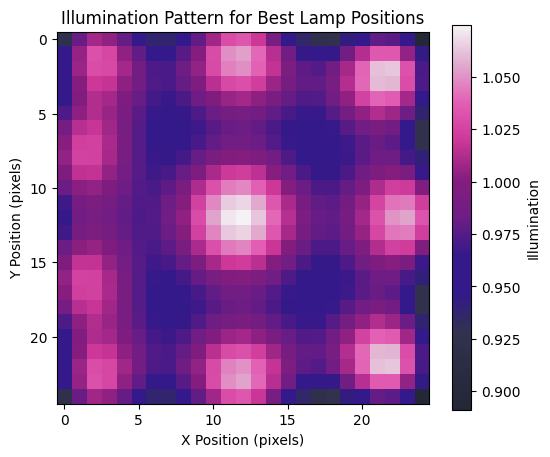

In [103]:
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#232736', '#292c42', '#32324f', '#33198a', '#33198a', '#6e1d85', '#851d7e', '#cc3798', '#e35fb5', '#e0abce', '#f5f2f5'])

# Plot the colormap.
plt.figure(figsize=(6, 5))
plt.title("Illumination Pattern for Best Lamp Positions")
plt.imshow(l_best_grid, cmap=custom_cmap)  
plt.colorbar(label='Illumination')
plt.xlabel("X Position (pixels)")
plt.ylabel("Y Position (pixels)")
plt.show()


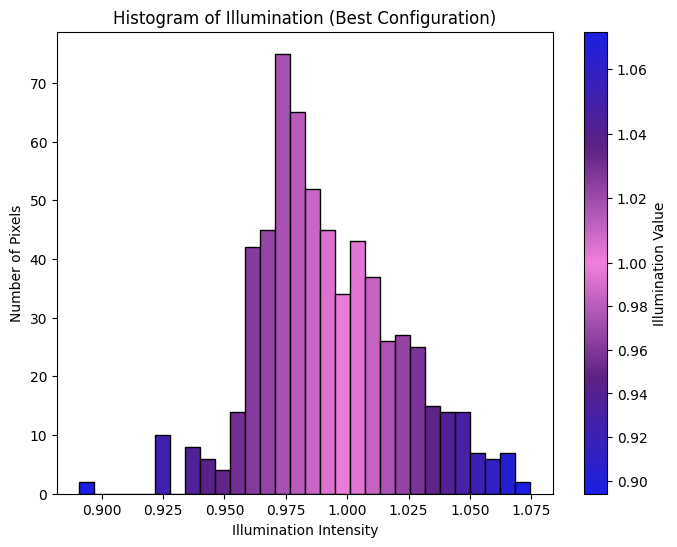

In [96]:
# create hist and patches
fig, ax = plt.subplots(figsize=(8, 6))
counts, bins, patches = ax.hist(l_best, bins=30, edgecolor='black')

# Compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#1b1fe3', '#5d2185', '#f280dd','#5d2185',  '#1b1fe3'])

# Initialize the norm with bin center == 1
norm = TwoSlopeNorm(vmin=bin_centers.min(), vcenter=1, vmax=bin_centers.max())

# Map colors to each bar based on the center of the bin
for center, patch in zip(bin_centers, patches):
    color = custom_cmap(norm(center))
    patch.set_facecolor(color)

ax.set_title('Histogram of Illumination (Best Configuration)')
ax.set_xlabel('Illumination Intensity')
ax.set_ylabel('Number of Pixels')

# Create colorbar and initialize ax 
sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Illumination Value')


plt.show()

### **Comparison of Least Squares (LS), Random Search, and Differential Evolution Optimization Methods**


####  **Least Squares (LS) Approach**
- **Observations:**
  - The **illumination pattern** is smoother than the baseline (all lamps at power 1) but still shows some **non-uniformity**.
  - The **histogram** is relatively **narrow**, indicating an improved **distribution of illumination intensities** compared to the unoptimized case.
  - The **RMS error** is **lower than the initial setup**, but there is still room for improvement.


####  **Random Search Approach**
- **Observations:**
  - The **illumination pattern** varies significantly based on random placements, with some areas experiencing **uneven lighting**.
  - The **histogram is wider**, meaning there is more **variation in pixel illumination**.
  - The **RMS error** is **higher than LS**, indicating that random search does not always find the optimal configuration.


#### **Differential Evolution Approach**
- **Observations:**
  - The **illumination pattern** is the **most uniform**, with a balanced spread of light across the area.
  - The **histogram** is the **narrowest**, suggesting that **more pixels receive illumination values closer to 1**.
  - The **RMS error is the lowest**, confirming that DE **outperforms both LS and Random Search**.



#### **Conclusion:**  
- **Least Squares** provides a **good starting point** but lacks flexibility in lamp positioning.  
- **Random Search** explores different configurations but is **not systematic**, leading to **inconsistent results**.  
- **Differential Evolution** **outperforms** both, finding the **best lamp positions** and achieving **the lowest RMS error** with the **most uniform illumination pattern**.
